In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
foods = pd.read_csv('../data/processed/foods_cleaned.csv')

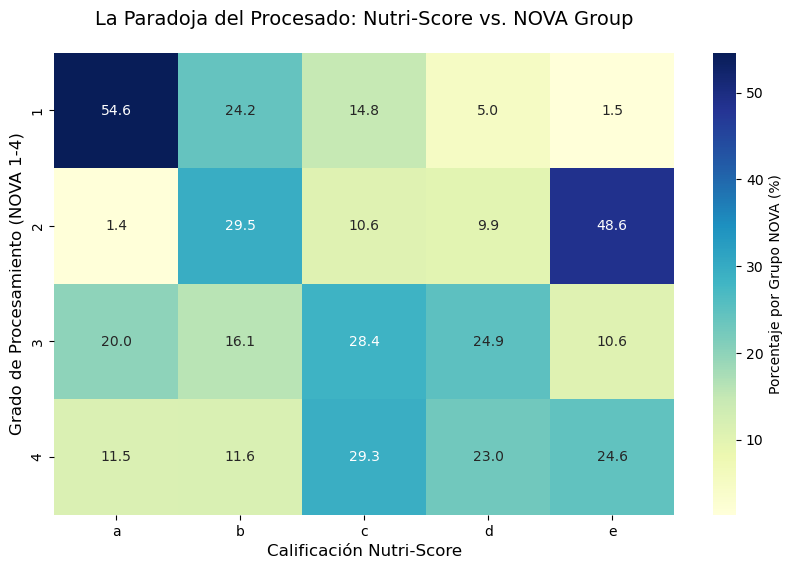

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Creamos un DataFrame temporal filtrando el "ruido"
# Excluimos 'not-applicable', 'unknown' y el grupo 0 de NOVA
df_paradox = foods[
    (foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])) & 
    (foods['nova_group'] > 0)
].copy()

# 2. Generamos la tabla cruzada con porcentajes por fila (frecuencia relativa)
cross_tab = pd.crosstab(
    df_paradox['nova_group'], 
    df_paradox['nutriscore_grade'], 
    normalize='index'
) * 100

# 3. Reordenamos las columnas para asegurar la jerarquía A -> E
cross_tab = cross_tab.reindex(columns=['a', 'b', 'c', 'd', 'e'])

# 4. Configuración y visualización del Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    cross_tab, 
    annot=True, 
    cmap="YlGnBu", 
    fmt=".1f", 
    cbar_kws={'label': 'Porcentaje por Grupo NOVA (%)'}
)

plt.title("La Paradoja del Procesado: Nutri-Score vs. NOVA Group", fontsize=14, pad=20)
plt.ylabel("Grado de Procesamiento (NOVA 1-4)", fontsize=12)
plt.xlabel("Calificación Nutri-Score", fontsize=12)

plt.show()

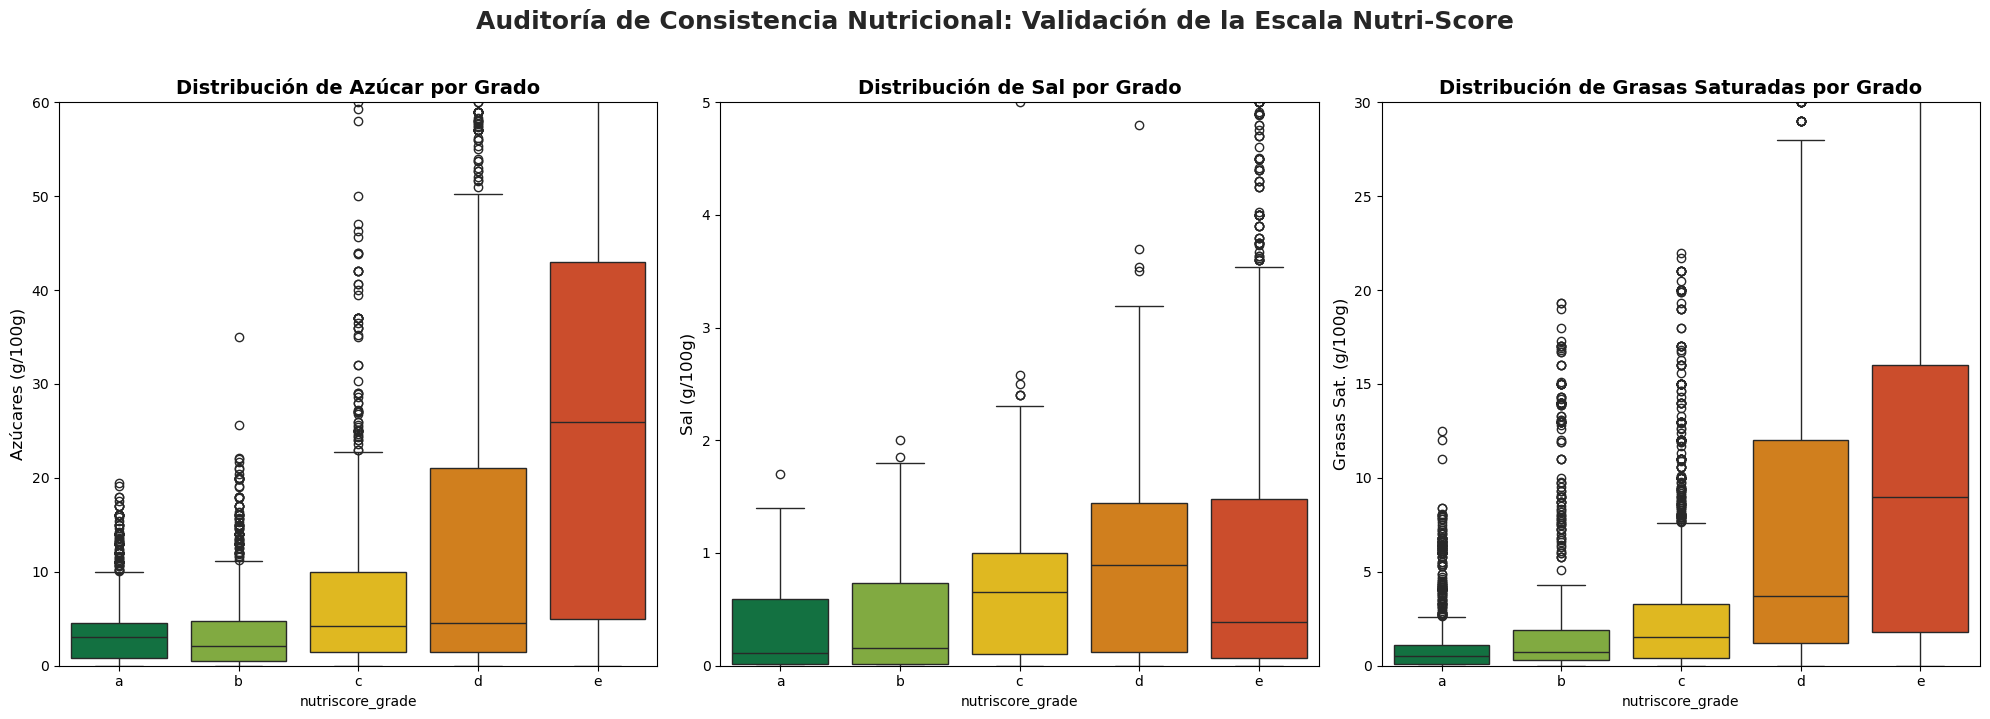

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# 1. Filtramos solo los productos con nota válida
df_veracidad = foods[foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])].copy()

# 2. Definimos la paleta oficial del Nutri-Score (Colores reales)
# Estos son los códigos hex aproximados de la identidad visual oficial
nutri_palette = {
    'a': '#038141', # Verde oscuro
    'b': '#85BB2F', # Verde claro
    'c': '#FECB02', # Amarillo/Ocre
    'd': '#EE8100', # Naranja
    'e': '#E63E11'  # Rojo/Naranja oscuro
}

order = ['a', 'b', 'c', 'd', 'e']

# 3. Configuramos el lienzo
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
sns.set_style("whitegrid")

# Gráfico 1: Azúcares
sns.boxplot(ax=axes[0], x='nutriscore_grade', y='sugars_100g', data=df_veracidad, 
            order=order, palette=nutri_palette, hue='nutriscore_grade', legend=False)
axes[0].set_title('Distribución de Azúcar por Grado', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Azúcares (g/100g)', fontsize=12)
axes[0].set_ylim(0, 60)

# Gráfico 2: Sal
sns.boxplot(ax=axes[1], x='nutriscore_grade', y='salt_100g', data=df_veracidad, 
            order=order, palette=nutri_palette, hue='nutriscore_grade', legend=False)
axes[1].set_title('Distribución de Sal por Grado', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Sal (g/100g)', fontsize=12)
axes[1].set_ylim(0, 5)

# Gráfico 3: Grasas Saturadas
sns.boxplot(ax=axes[2], x='nutriscore_grade', y='saturated-fat_100g', data=df_veracidad, 
            order=order, palette=nutri_palette, hue='nutriscore_grade', legend=False)
axes[2].set_title('Distribución de Grasas Saturadas por Grado', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Grasas Sat. (g/100g)', fontsize=12)
axes[2].set_ylim(0, 30)

plt.suptitle("Auditoría de Consistencia Nutricional: Validación de la Escala Nutri-Score", 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()

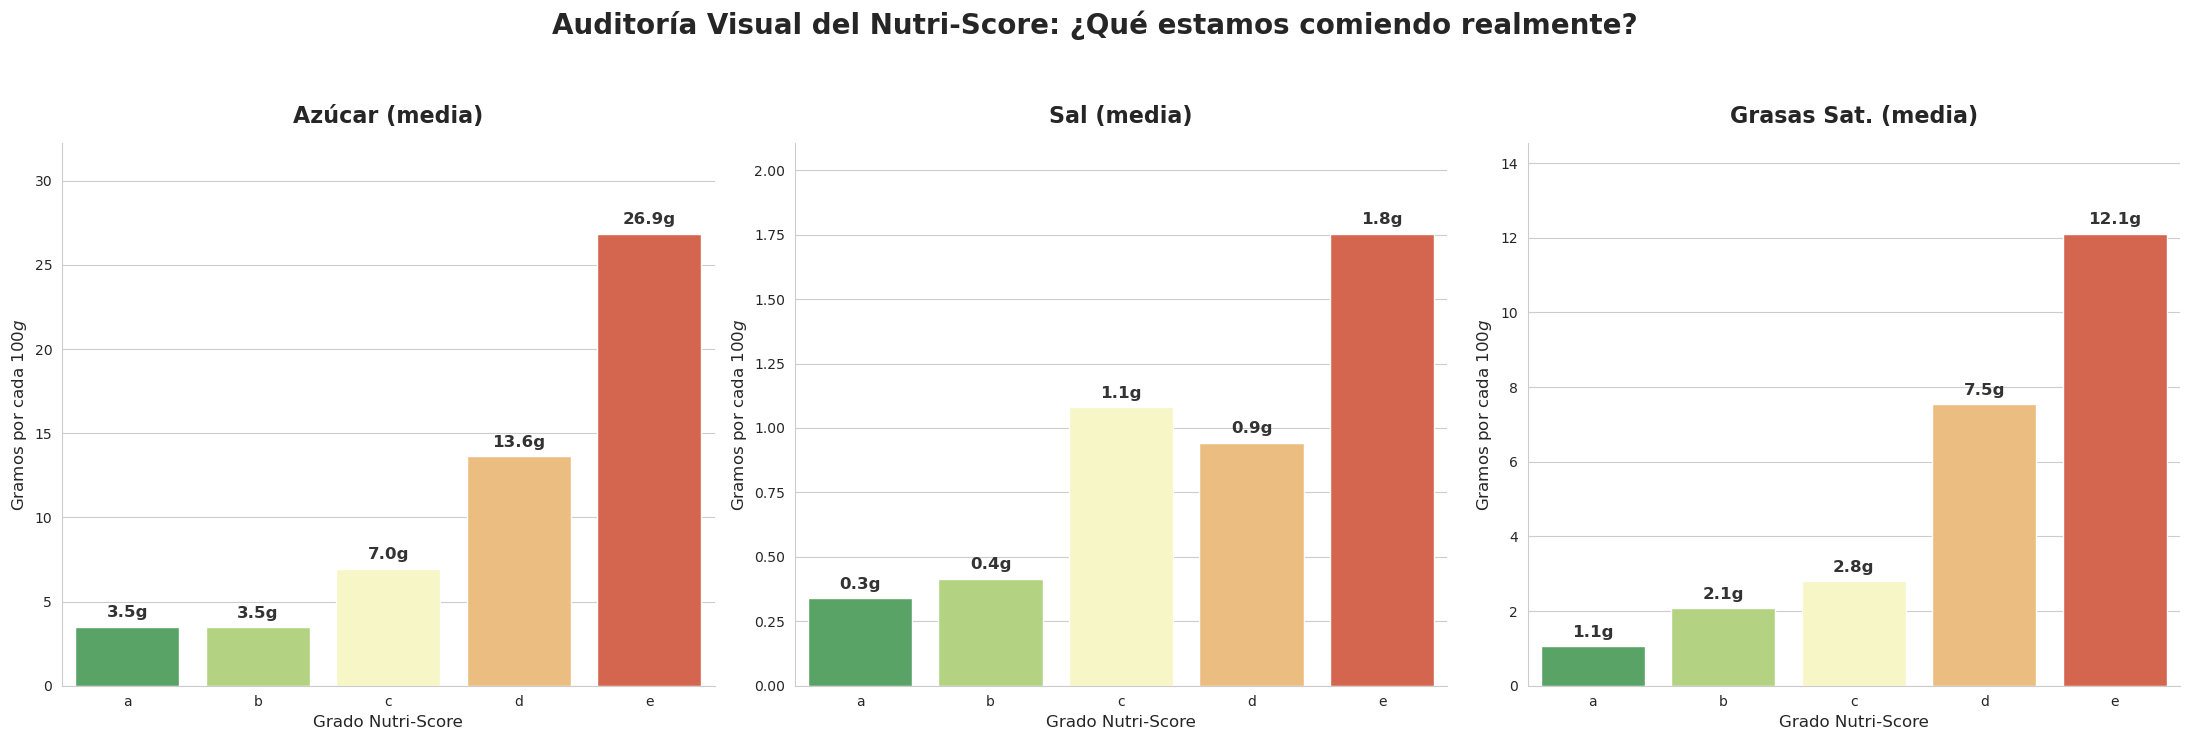

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparación de datos: calculamos las medias por grado
df_veracidad = foods[foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])].copy()
nutrientes = ['sugars_100g', 'salt_100g', 'saturated-fat_100g']
titulos = ['Azúcar (media)', 'Sal (media)', 'Grasas Sat. (media)']
unidades = ['g', 'g', 'g']

medias = df_veracidad.groupby('nutriscore_grade')[nutrientes].mean().reset_index()

# 2. Configuración estética
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
palette = "RdYlGn_r"
order = ['a', 'b', 'c', 'd', 'e']

# 3. Generación de los 3 subplots
for i, nutriente in enumerate(nutrientes):
    ax = sns.barplot(
        ax=axes[i], 
        x='nutriscore_grade', 
        y=nutriente, 
        data=medias, 
        order=order, 
        palette=palette, 
        hue='nutriscore_grade', 
        legend=False
    )
    
    # Añadimos etiquetas de valor sobre cada barra
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}{unidades[i]}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points', 
                    fontsize=12, fontweight='bold', color='#333333')

    # Personalización de cada gráfico
    ax.set_title(titulos[i], fontsize=16, pad=15, fontweight='bold')
    ax.set_ylabel(f"Gramos por cada 100$g$", fontsize=12)
    ax.set_xlabel("Grado Nutri-Score", fontsize=12)
    ax.set_ylim(0, medias[nutriente].max() * 1.2) # Espacio para la etiqueta
    sns.despine(ax=ax)

plt.suptitle("Auditoría Visual del Nutri-Score: ¿Qué estamos comiendo realmente?", fontsize=20, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

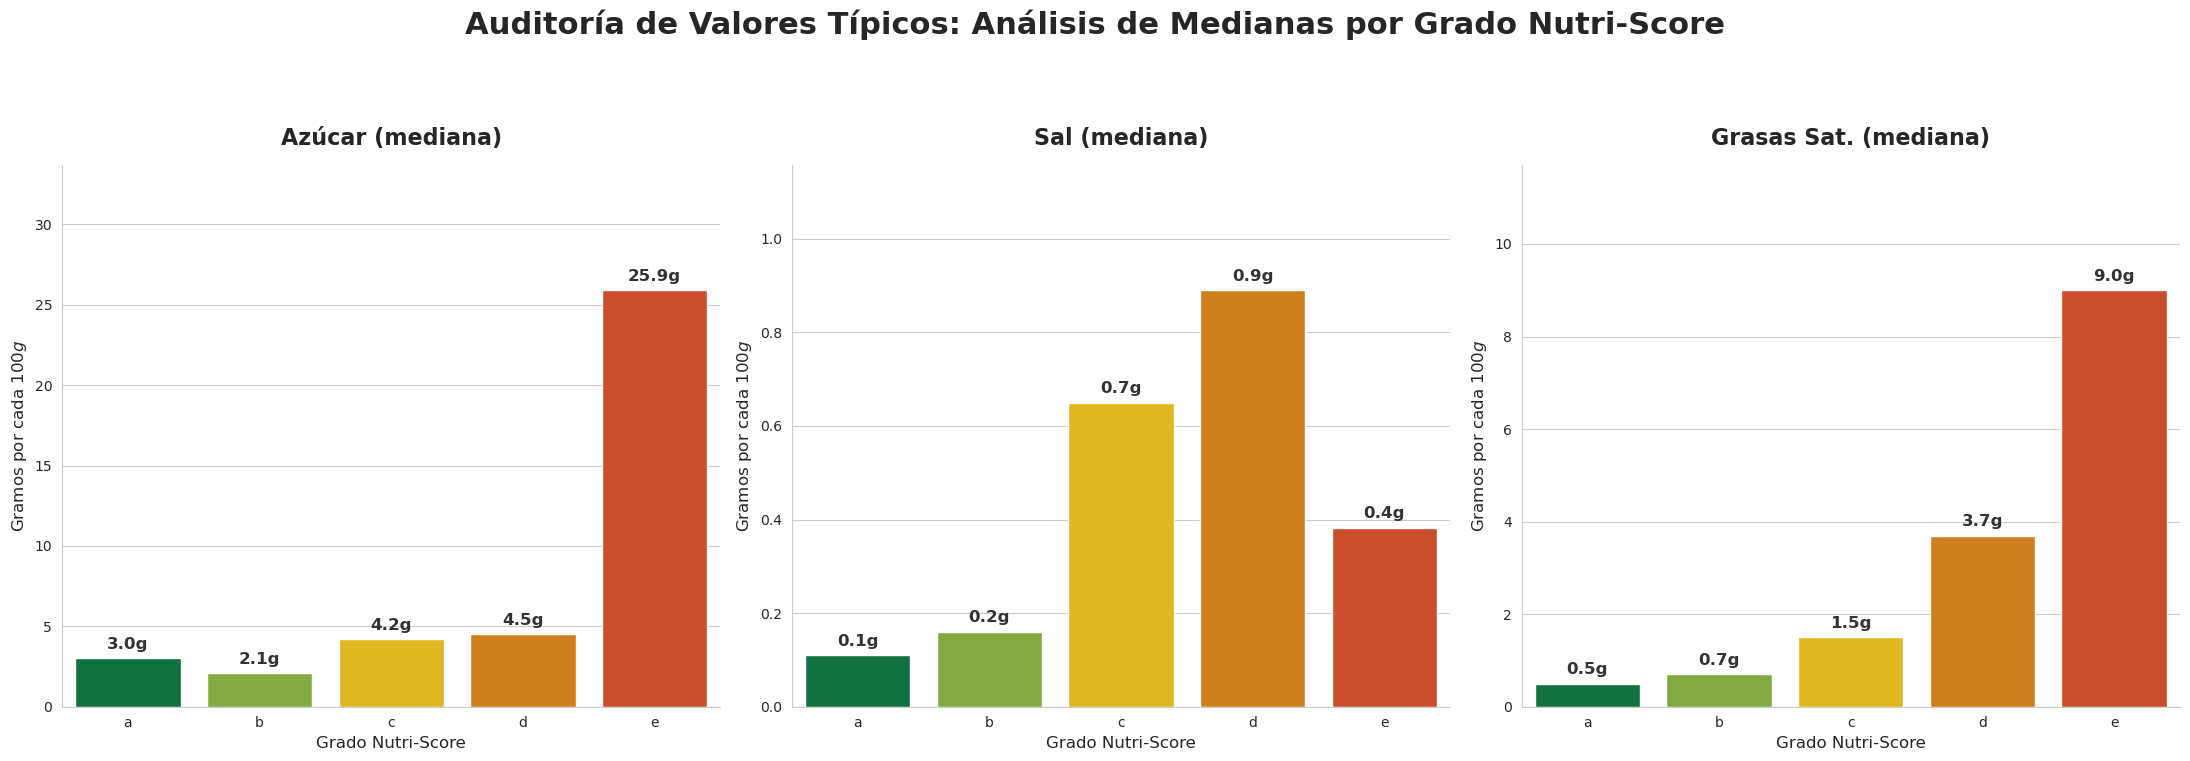

In [6]:
# --- [ED-10] AUDITORÍA POR MEDIANAS: EL PRODUCTO TÍPICO ---

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparación de datos: calculamos las MEDIANAS por grado
df_veracidad = foods[foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])].copy()

nutrientes = ['sugars_100g', 'salt_100g', 'saturated-fat_100g']
titulos = ['Azúcar (mediana)', 'Sal (mediana)', 'Grasas Sat. (mediana)']
unidades = ['g', 'g', 'g']

# Agrupamos por mediana
medianas = df_veracidad.groupby('nutriscore_grade')[nutrientes].median().reset_index()

# 2. Configuración estética (Colores oficiales Nutri-Score)
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

nutri_palette = {
    'a': '#038141', 'b': '#85BB2F', 'c': '#FECB02', 
    'd': '#EE8100', 'e': '#E63E11'
}
order = ['a', 'b', 'c', 'd', 'e']

# 3. Generación de los 3 subplots
for i, nutriente in enumerate(nutrientes):
    ax = sns.barplot(
        ax=axes[i], 
        x='nutriscore_grade', 
        y=nutriente, 
        data=medianas, 
        order=order, 
        palette=nutri_palette, 
        hue='nutriscore_grade', 
        legend=False
    )
    
    # Añadimos etiquetas de valor sobre cada barra
    for p in ax.patches:
        val = p.get_height()
        ax.annotate(f'{val:.1f}{unidades[i]}', 
                    (p.get_x() + p.get_width() / 2., val), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points', 
                    fontsize=12, fontweight='bold', color='#333333')

    # Personalización académica
    ax.set_title(titulos[i], fontsize=16, pad=15, fontweight='bold')
    ax.set_ylabel(r"Gramos por cada 100$g$", fontsize=12)
    ax.set_xlabel("Grado Nutri-Score", fontsize=12)
    
    # Ajustamos el límite superior para que no corten las etiquetas
    ax.set_ylim(0, medianas[nutriente].max() * 1.3)
    sns.despine(ax=ax)

plt.suptitle("Auditoría de Valores Típicos: Análisis de Medianas por Grado Nutri-Score", 
             fontsize=22, fontweight='bold', y=1.08)
plt.tight_layout()
plt.show()

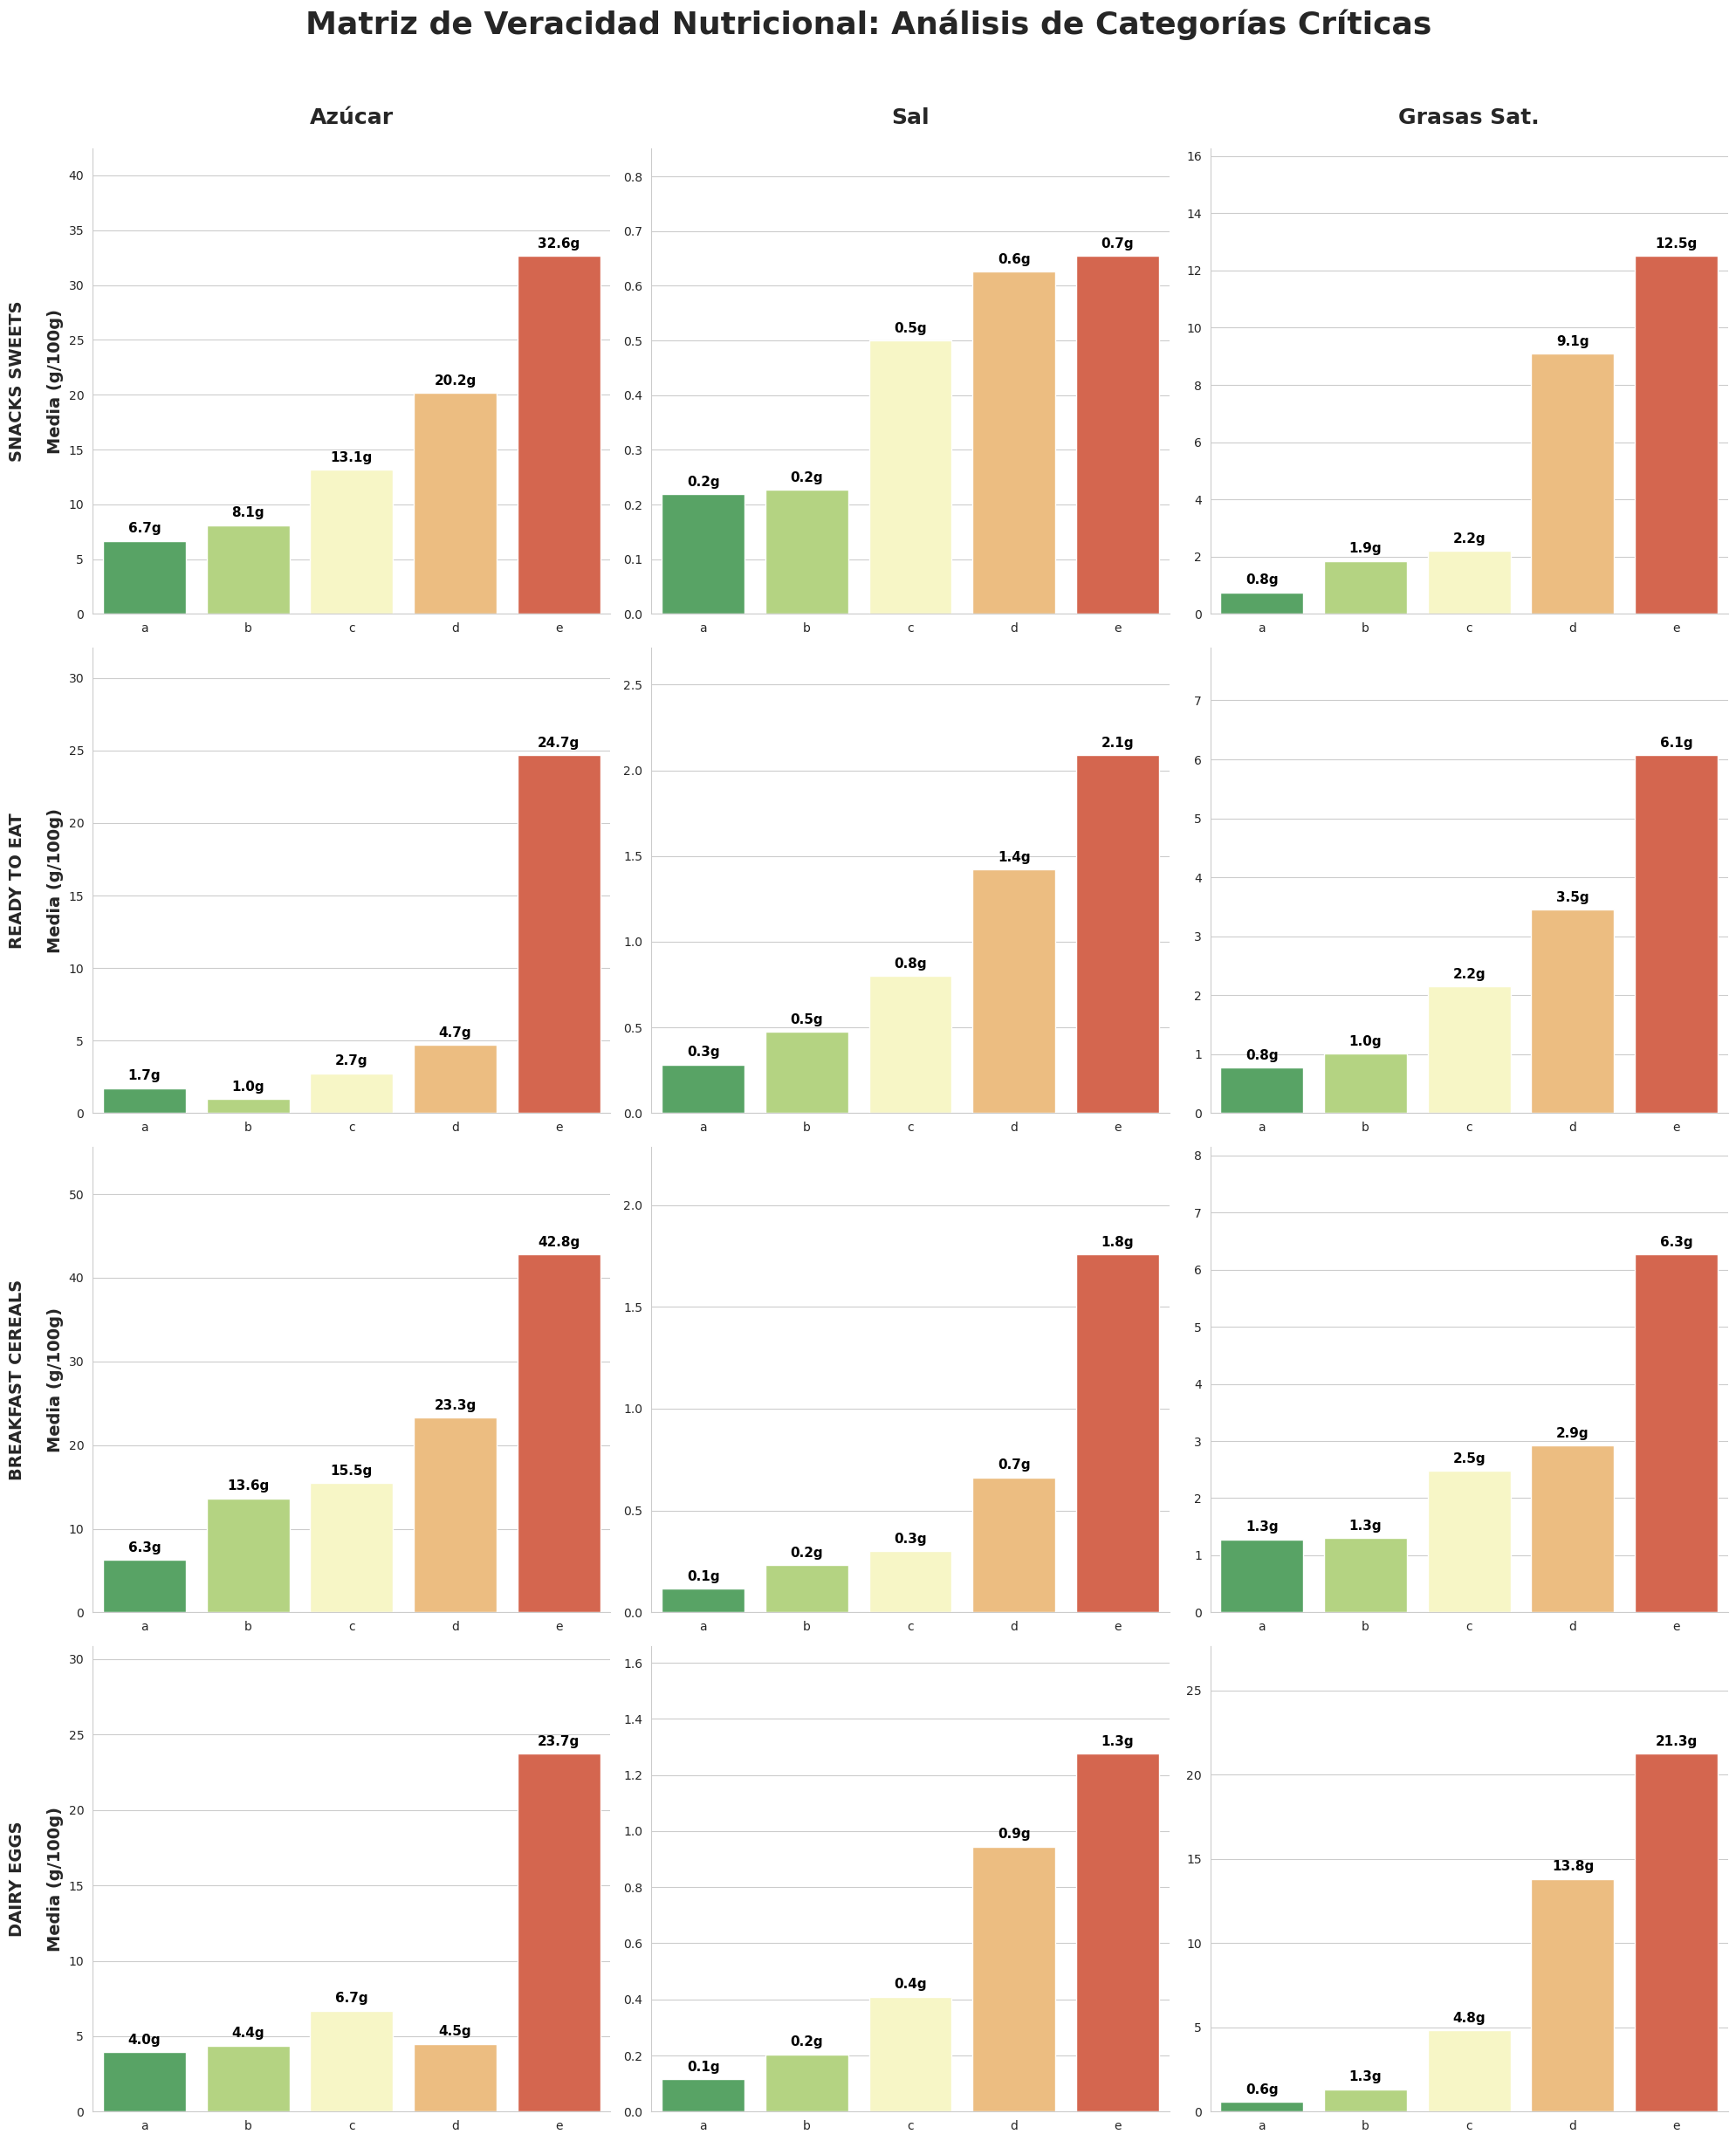

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Preparación: Incluimos 'breakfast_cereals' en el Top 4
top_categories = ['snacks_sweets', 'ready_to_eat', 'breakfast_cereals', 'dairy_eggs']
nutrientes = ['sugars_100g', 'salt_100g', 'saturated-fat_100g']
unidades = ['g', 'g', 'g']
titulos_nutri = ['Azúcar', 'Sal', 'Grasas Sat.']

# 2. Filtramos el dataset 'foods'
df_plot = foods[
    (foods['category_unified'].isin(top_categories)) & 
    (foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e']))
].copy()

# 3. Configuración de la matriz 4x3
sns.set_style("whitegrid")
fig, axes = plt.subplots(4, 3, figsize=(20, 24))
palette = "RdYlGn_r"
order = ['a', 'b', 'c', 'd', 'e']

# 4. Bucle para generar la matriz
for row, cat in enumerate(top_categories):
    for col, nutri in enumerate(nutrientes):
        ax = axes[row, col]
        
        # Filtramos datos para esta celda específica
        data_subset = df_plot[df_plot['category_unified'] == cat]
        
        # Calculamos la media para las barras
        medias_subset = data_subset.groupby('nutriscore_grade')[nutri].mean().reindex(order).reset_index()
        
        # Dibujamos el barplot
        sns.barplot(
            ax=ax, x='nutriscore_grade', y=nutri, data=medias_subset,
            order=order, palette=palette, hue='nutriscore_grade', legend=False
        )
        
        # Añadimos etiquetas de valor sobre las barras
        for p in ax.patches:
            val = p.get_height()
            if not pd.isna(val) and val > 0:
                ax.annotate(f'{val:.1f}{unidades[col]}', 
                            (p.get_x() + p.get_width() / 2., val), 
                            ha='center', va='center', 
                            xytext=(0, 10), textcoords='offset points', 
                            fontsize=11, fontweight='bold', color='black')

        # Títulos de columna (solo primera fila)
        if row == 0:
            ax.set_title(f"{titulos_nutri[col]}", fontsize=18, fontweight='bold', pad=20)
            
        # Etiquetas de fila (Categoría a la izquierda)
        if col == 0:
            nombre_label = cat.replace('_', ' ').upper()
            ax.set_ylabel(f"{nombre_label}\n\nMedia (g/100g)", fontsize=14, fontweight='bold')
        else:
            ax.set_ylabel("")
            
        ax.set_xlabel("")
        
        # Ajuste dinámico del límite Y para evitar cortes de etiquetas
        max_val = medias_subset[nutri].max()
        if max_val > 0:
            ax.set_ylim(0, max_val * 1.3)
        else:
            ax.set_ylim(0, 1)
            
        sns.despine(ax=ax)

plt.suptitle("Matriz de Veracidad Nutricional: Análisis de Categorías Críticas", 
             fontsize=26, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

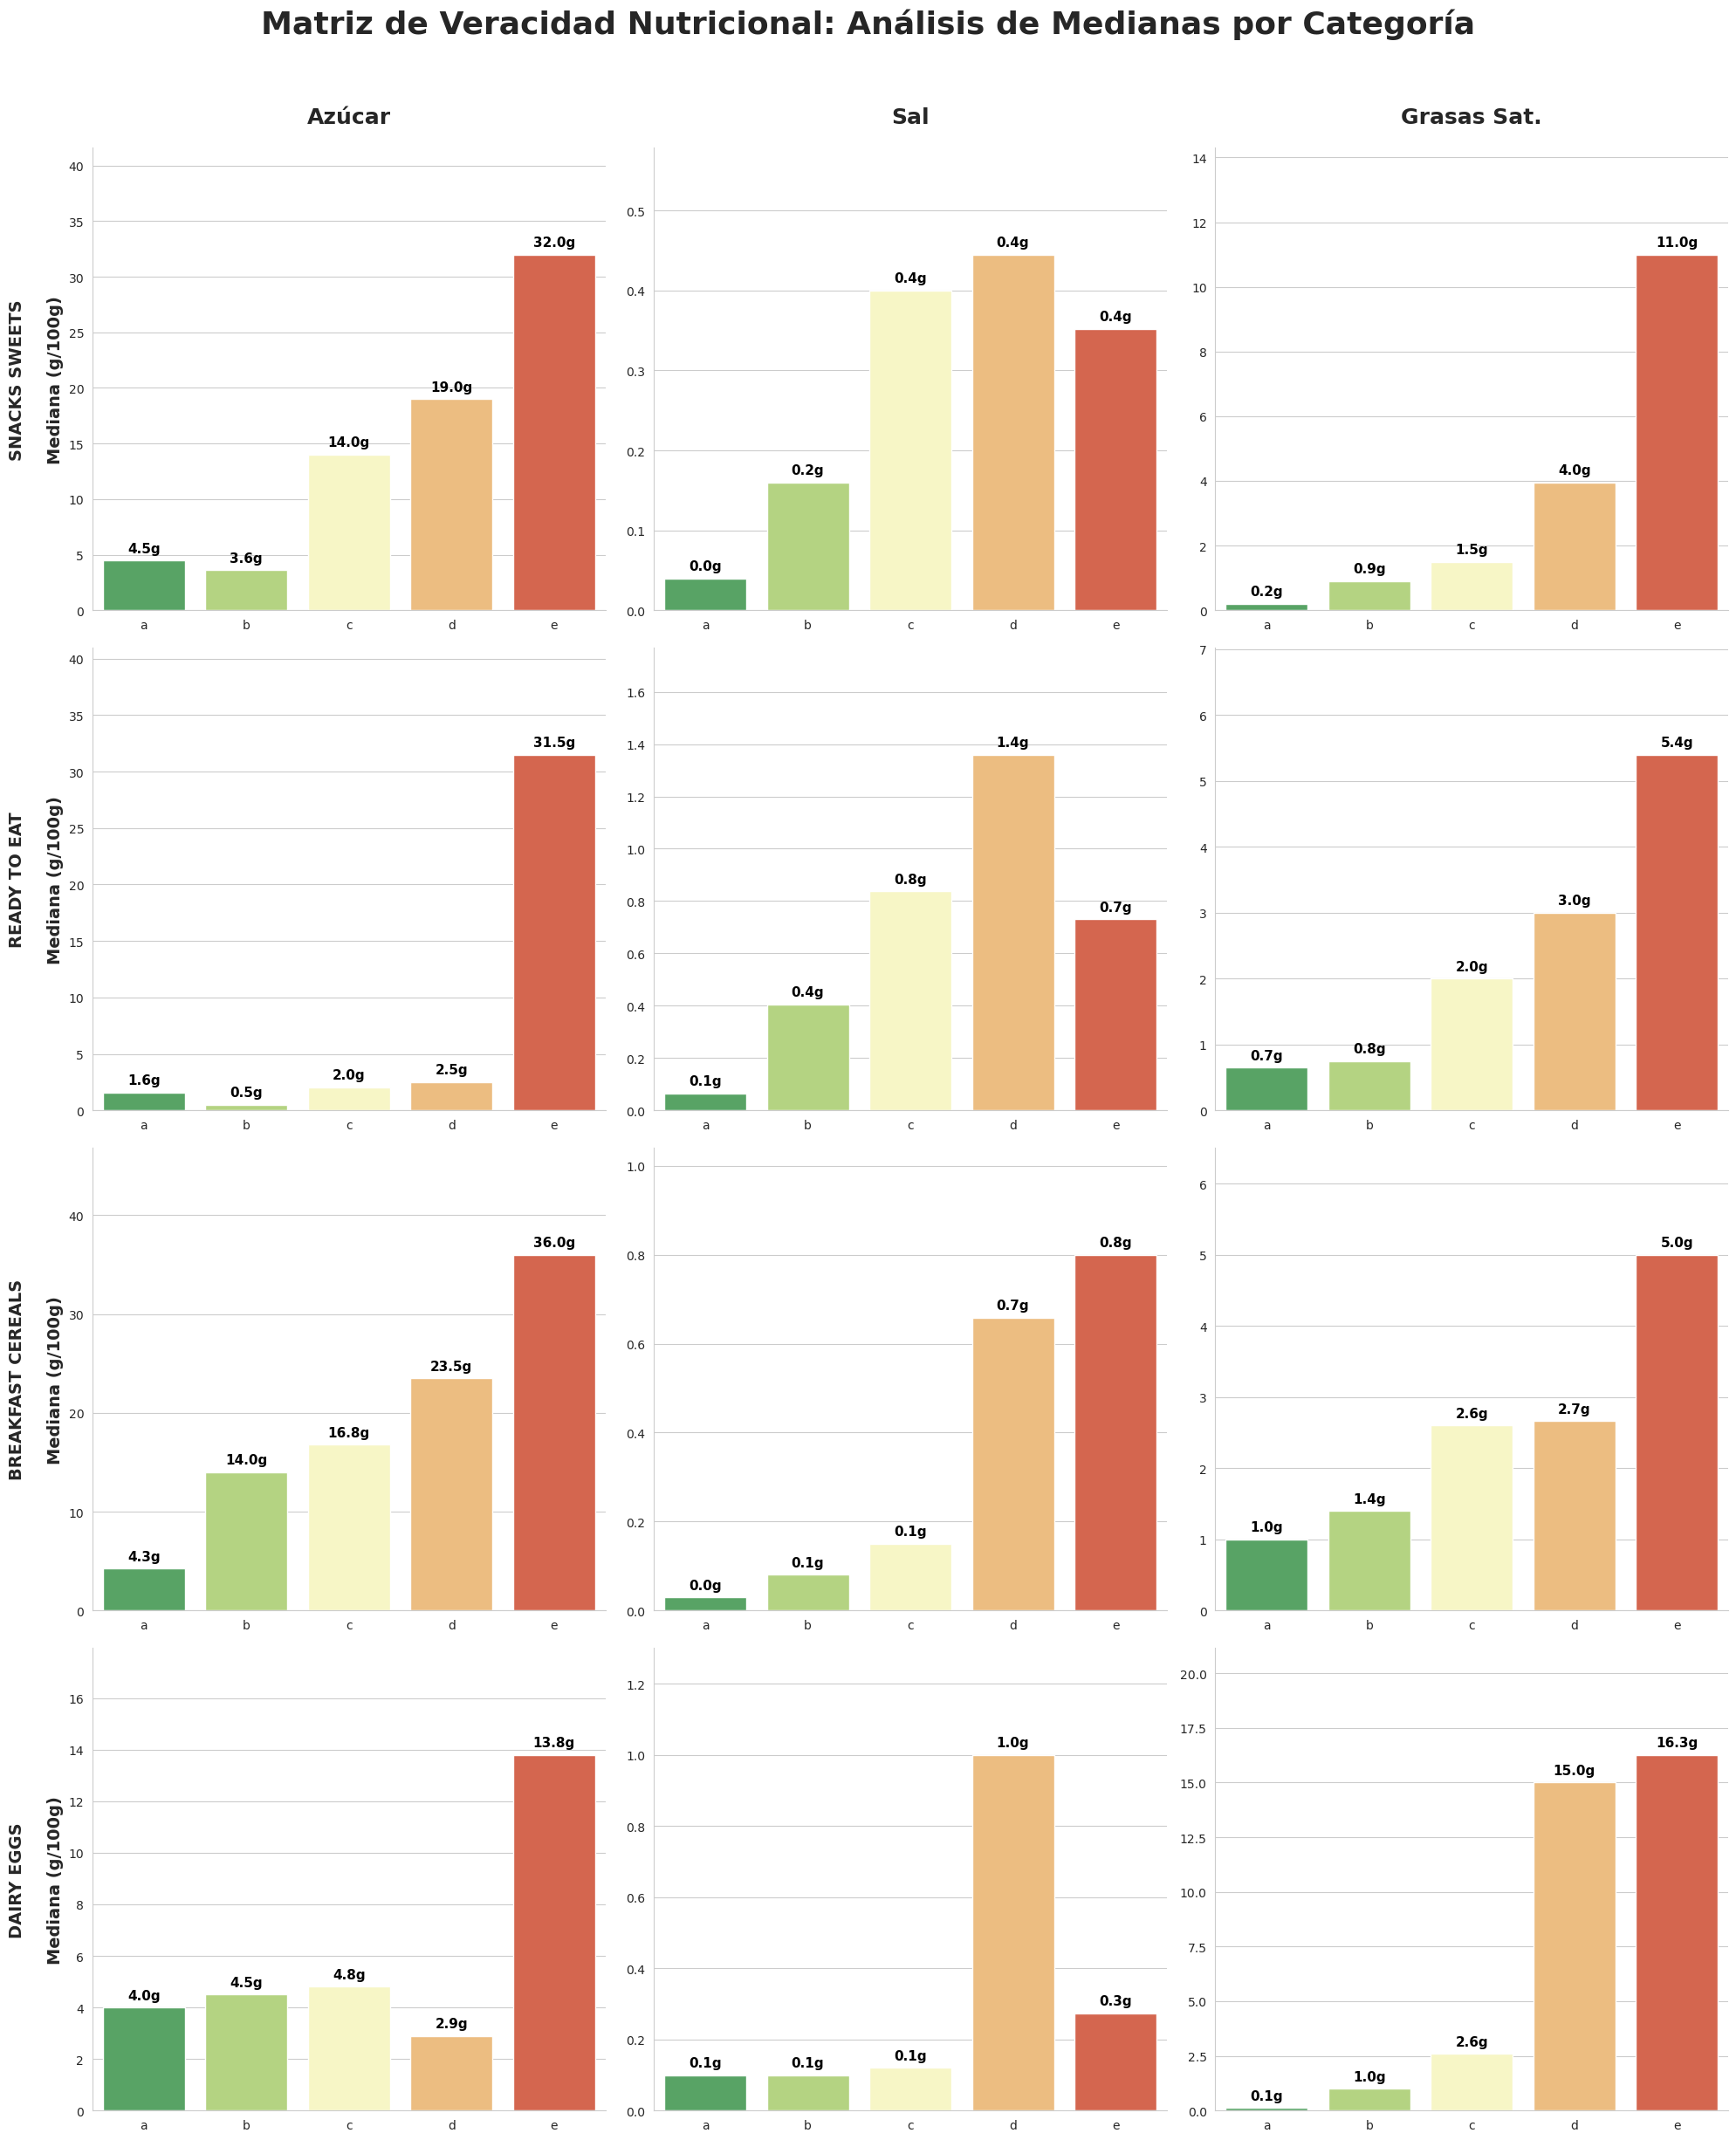

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Preparación: Incluimos 'breakfast_cereals' en el Top 4
top_categories = ['snacks_sweets', 'ready_to_eat', 'breakfast_cereals', 'dairy_eggs']
nutrientes = ['sugars_100g', 'salt_100g', 'saturated-fat_100g']
unidades = ['g', 'g', 'g']
titulos_nutri = ['Azúcar', 'Sal', 'Grasas Sat.']

# 2. Filtramos el dataset 'foods'
df_plot = foods[
    (foods['category_unified'].isin(top_categories)) & 
    (foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e']))
].copy()

# 3. Configuración de la matriz 4x3
sns.set_style("whitegrid")
fig, axes = plt.subplots(4, 3, figsize=(20, 24))
palette = "RdYlGn_r"
order = ['a', 'b', 'c', 'd', 'e']

# 4. Bucle para generar la matriz
for row, cat in enumerate(top_categories):
    for col, nutri in enumerate(nutrientes):
        ax = axes[row, col]
        
        # Filtramos datos para esta celda específica
        data_subset = df_plot[df_plot['category_unified'] == cat]
        
        # CAMBIO CLAVE: Calculamos la MEDIANA en lugar de la media
        medianas_subset = data_subset.groupby('nutriscore_grade')[nutri].median().reindex(order).reset_index()
        
        # Dibujamos el barplot
        sns.barplot(
            ax=ax, x='nutriscore_grade', y=nutri, data=medianas_subset,
            order=order, palette=palette, hue='nutriscore_grade', legend=False
        )
        
        # Añadimos etiquetas de valor sobre las barras
        for p in ax.patches:
            val = p.get_height()
            if not pd.isna(val) and val >= 0: # Ajustado para incluir 0
                ax.annotate(f'{val:.1f}{unidades[col]}', 
                            (p.get_x() + p.get_width() / 2., val), 
                            ha='center', va='center', 
                            xytext=(0, 10), textcoords='offset points', 
                            fontsize=11, fontweight='bold', color='black')

        # Títulos de columna (solo primera fila)
        if row == 0:
            ax.set_title(f"{titulos_nutri[col]}", fontsize=18, fontweight='bold', pad=20)
            
        # Etiquetas de fila (Categoría a la izquierda)
        if col == 0:
            nombre_label = cat.replace('_', ' ').upper()
            ax.set_ylabel(f"{nombre_label}\n\nMediana (g/100g)", fontsize=14, fontweight='bold')
        else:
            ax.set_ylabel("")
            
        ax.set_xlabel("")
        
        # Ajuste dinámico del límite Y basado en la mediana
        max_val = medianas_subset[nutri].max()
        if max_val > 0:
            ax.set_ylim(0, max_val * 1.3)
        else:
            ax.set_ylim(0, 1)
            
        sns.despine(ax=ax)

plt.suptitle("Matriz de Veracidad Nutricional: Análisis de Medianas por Categoría", 
             fontsize=26, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

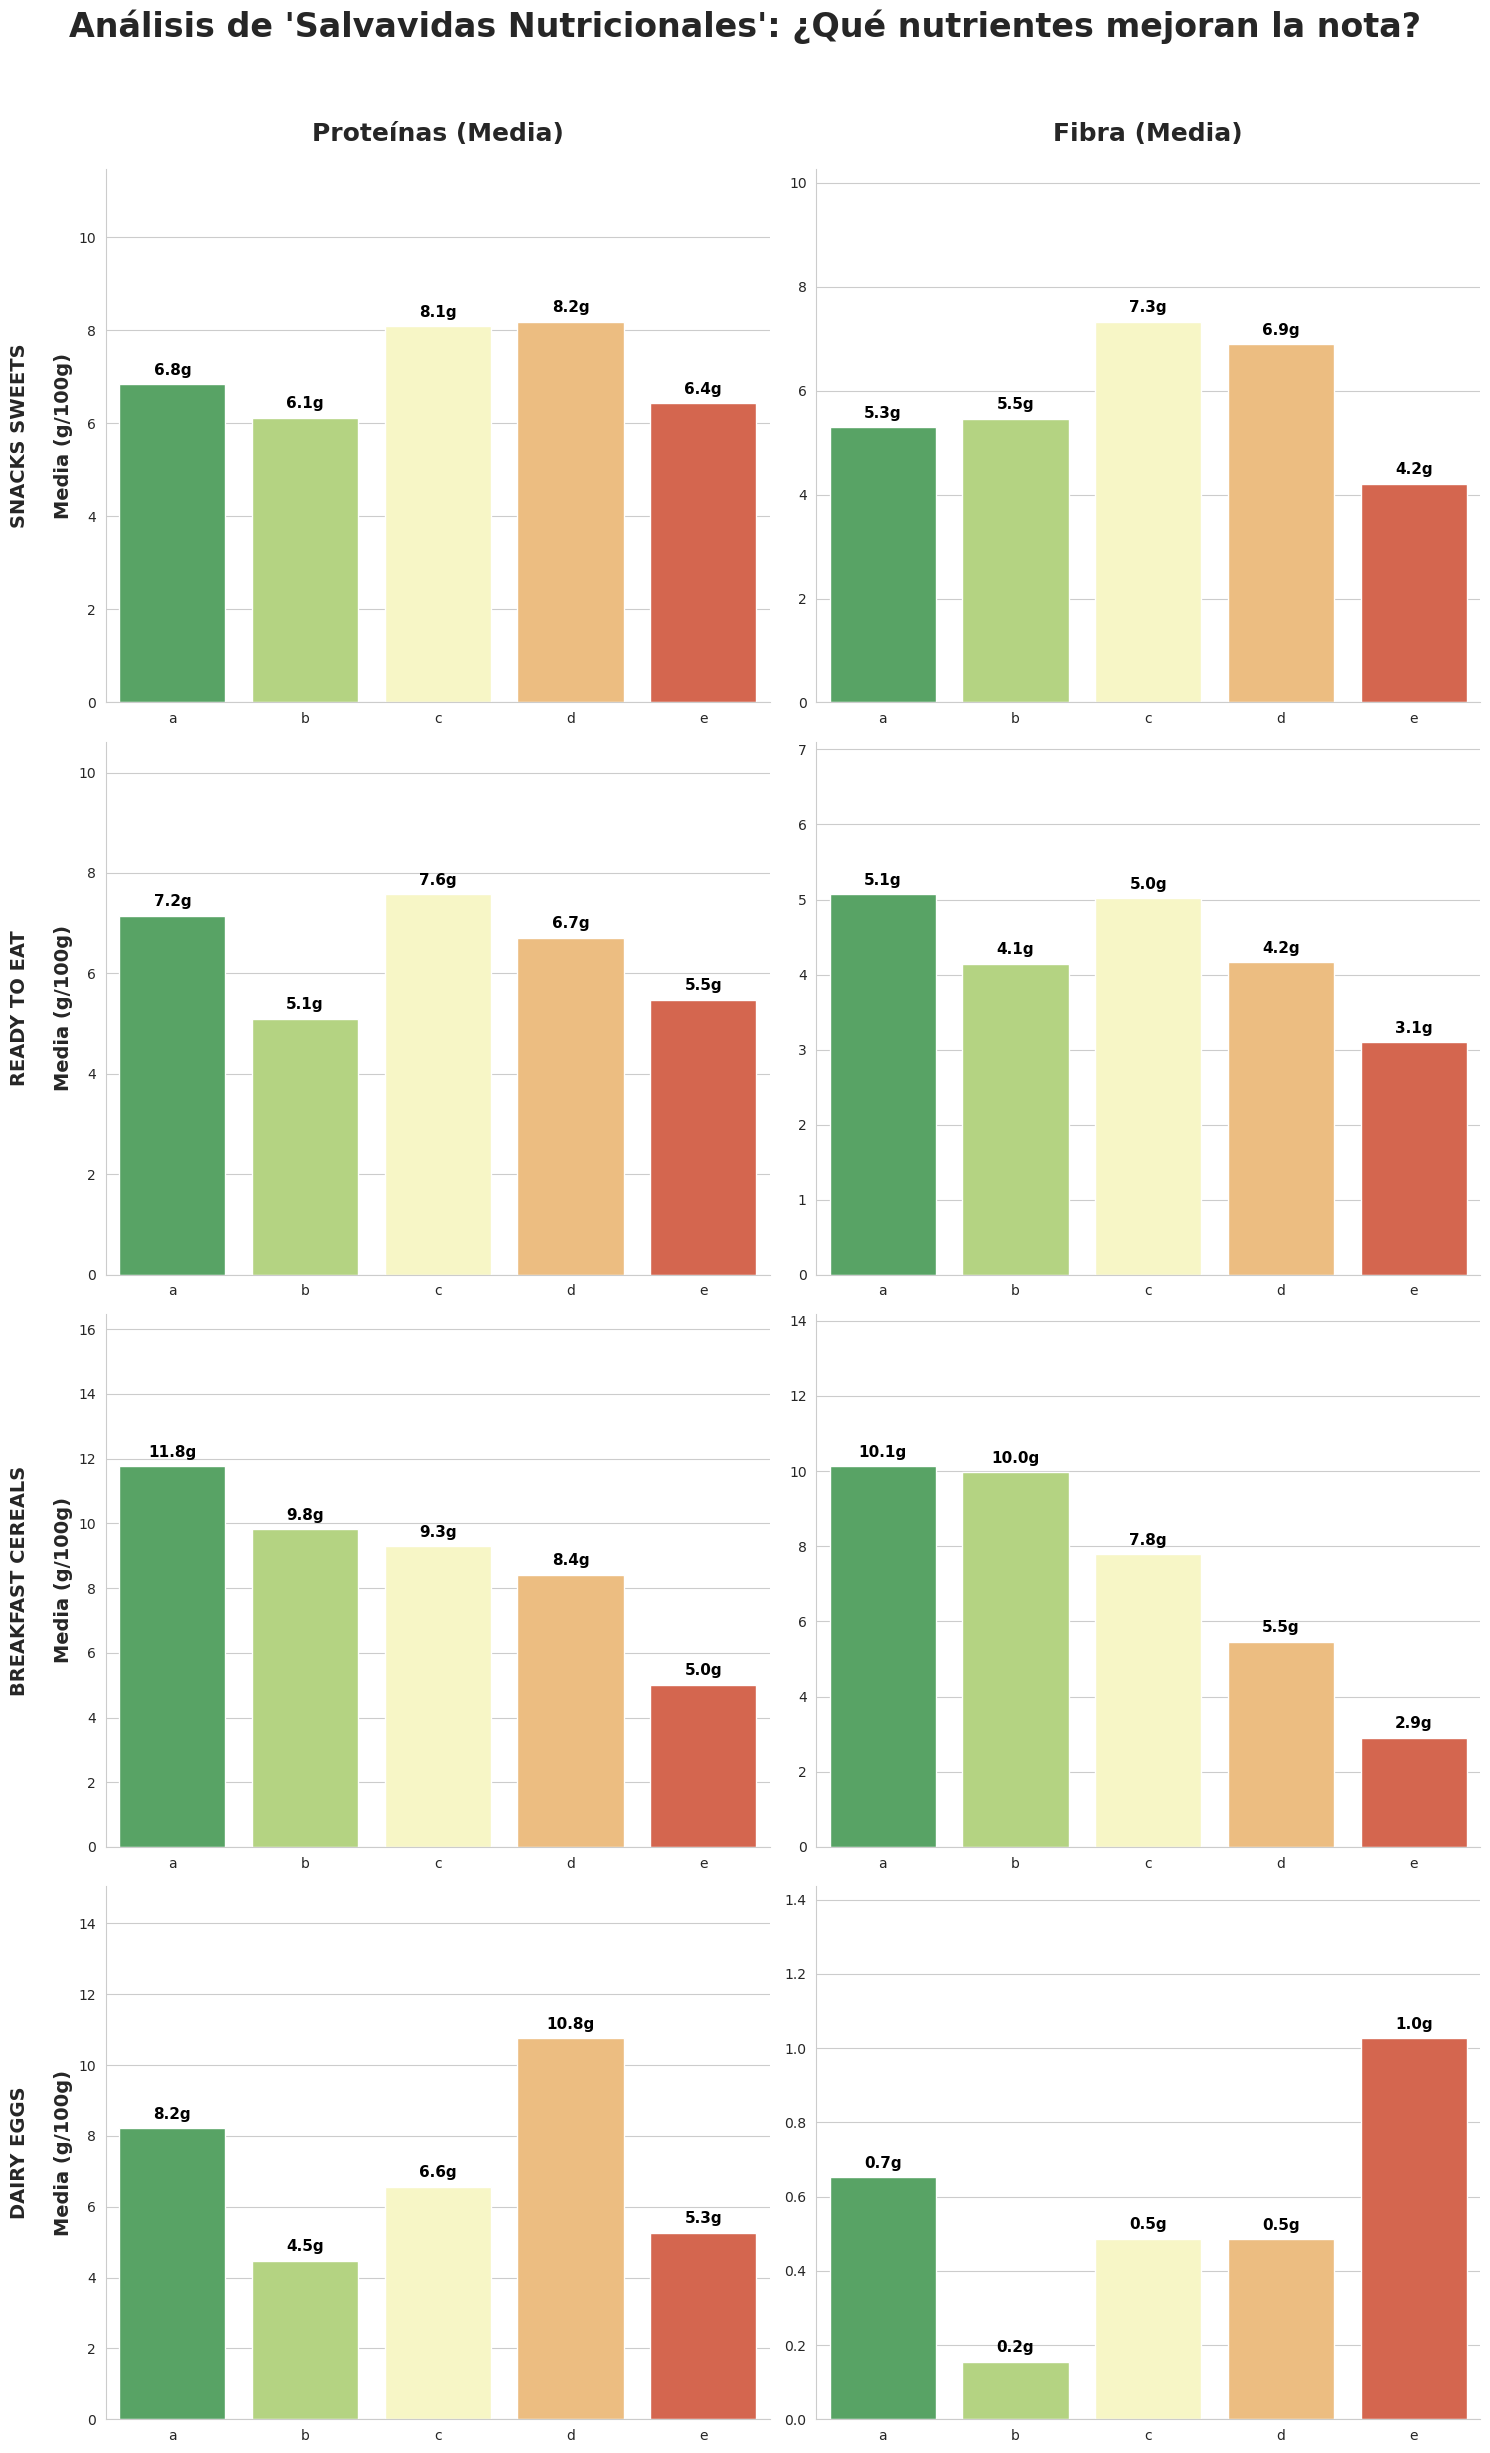

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Preparación: Añadimos 'breakfast_cereals' al Top 4 y nutrientes "positivos"
top_categories = ['snacks_sweets', 'ready_to_eat', 'breakfast_cereals', 'dairy_eggs']
nutrientes_pos = ['proteins_100g', 'fiber_100g']
titulos_pos = ['Proteínas (Media)', 'Fibra (Media)']

# Filtramos el dataset 'foods'
df_pos = foods[
    (foods['category_unified'].isin(top_categories)) & 
    (foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e']))
].copy()

# 2. Configuración de la matriz 4x2
sns.set_style("whitegrid")
fig, axes = plt.subplots(4, 2, figsize=(15, 24))
palette = "RdYlGn" # Invertimos la paleta para que el verde (bueno) esté en la 'A'
order = ['a', 'b', 'c', 'd', 'e']

# 3. Bucle para generar la matriz
for row, cat in enumerate(top_categories):
    for col, nutri in enumerate(nutrientes_pos):
        ax = axes[row, col]
        
        # Filtramos datos para esta celda específica
        data_subset = df_pos[df_pos['category_unified'] == cat]
        
        # Calculamos la media para las barras
        medias_subset = data_subset.groupby('nutriscore_grade')[nutri].mean().reindex(order).reset_index()
        
        # Dibujamos el barplot (usamos paleta 'RdYlGn' invertida para nutrientes positivos)
        sns.barplot(
            ax=ax, x='nutriscore_grade', y=nutri, data=medias_subset,
            order=order, palette="RdYlGn_r", hue='nutriscore_grade', legend=False
        )
        
        # Añadimos etiquetas de valor sobre las barras
        for p in ax.patches:
            val = p.get_height()
            if not pd.isna(val) and val > 0:
                ax.annotate(f'{val:.1f}g', 
                            (p.get_x() + p.get_width() / 2., val), 
                            ha='center', va='center', 
                            xytext=(0, 10), textcoords='offset points', 
                            fontsize=11, fontweight='bold', color='black')

        # Títulos de columna (solo primera fila)
        if row == 0:
            ax.set_title(f"{titulos_pos[col]}", fontsize=18, fontweight='bold', pad=20)
            
        # Etiquetas de fila (Categoría a la izquierda)
        if col == 0:
            nombre_label = cat.replace('_', ' ').upper()
            ax.set_ylabel(f"{nombre_label}\n\nMedia (g/100g)", fontsize=14, fontweight='bold')
        else:
            ax.set_ylabel("")
            
        ax.set_xlabel("")
        
        # Ajuste dinámico del límite Y
        max_val = medias_subset[nutri].max()
        if max_val > 0:
            ax.set_ylim(0, max_val * 1.4)
        else:
            ax.set_ylim(0, 1)
            
        sns.despine(ax=ax)

plt.suptitle("Análisis de 'Salvavidas Nutricionales': ¿Qué nutrientes mejoran la nota?", 
             fontsize=24, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

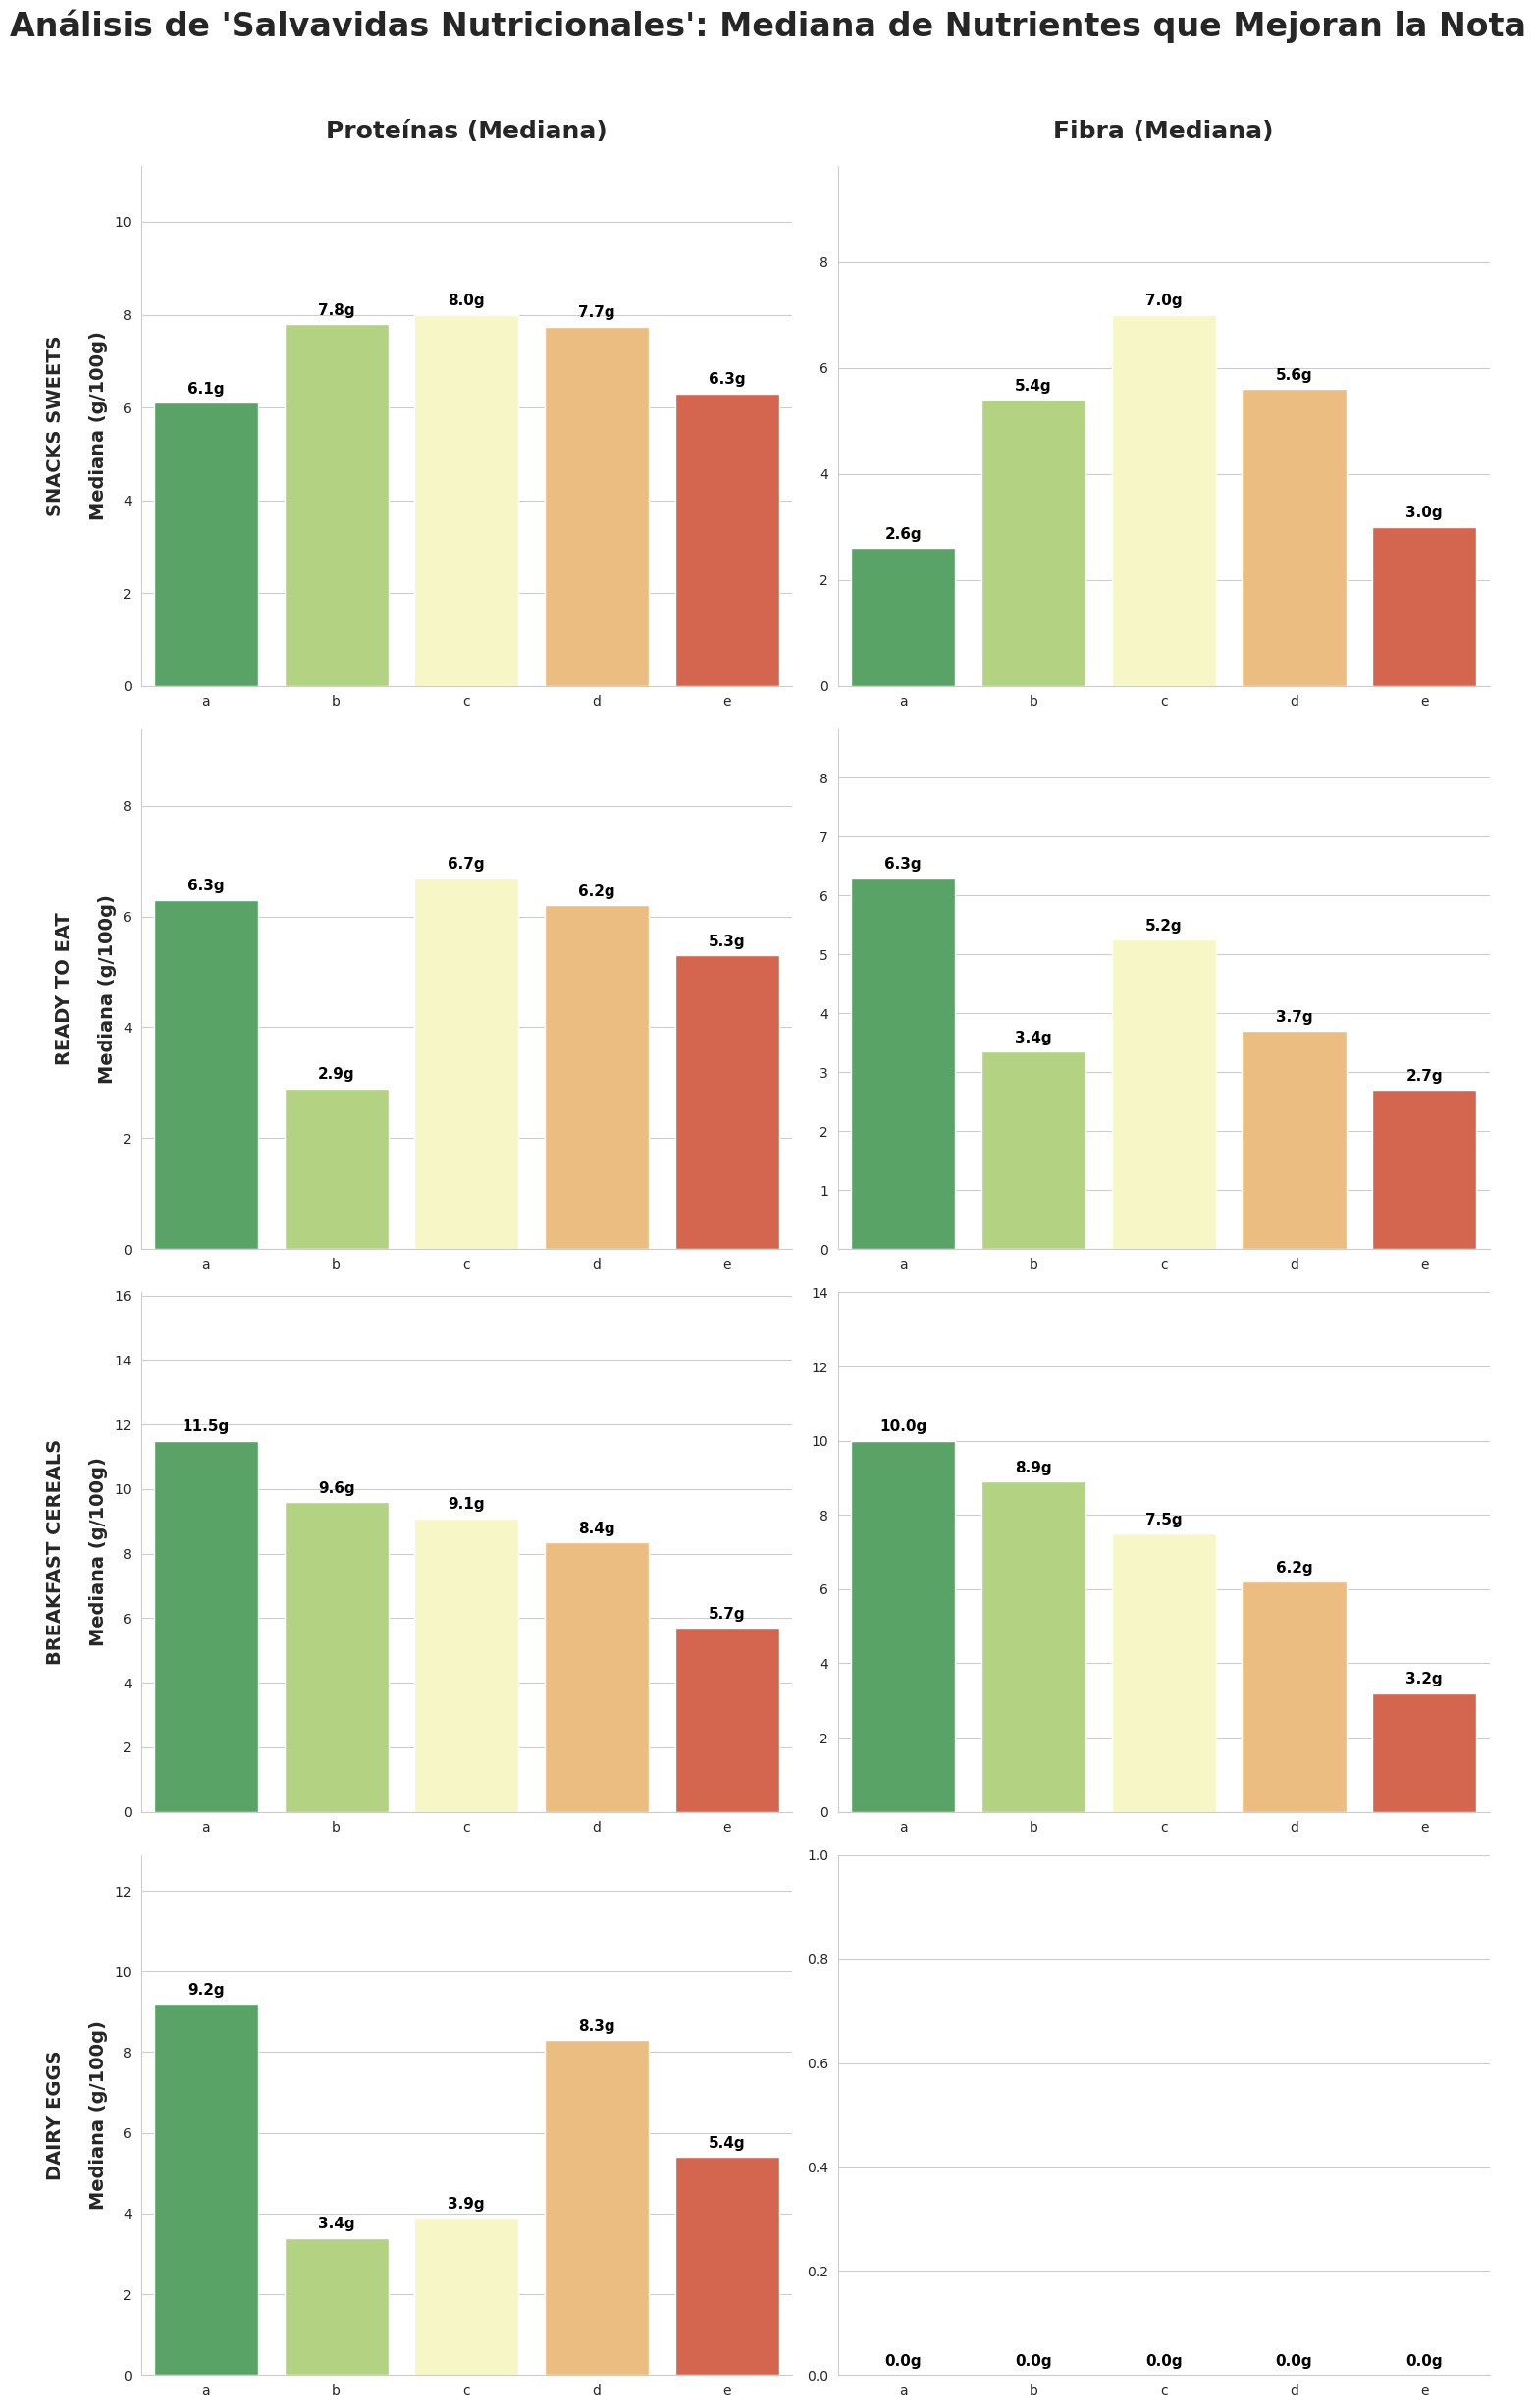

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Preparación: Añadimos 'breakfast_cereals' al Top 4 y nutrientes "positivos"
top_categories = ['snacks_sweets', 'ready_to_eat', 'breakfast_cereals', 'dairy_eggs']
nutrientes_pos = ['proteins_100g', 'fiber_100g']
# Actualizamos títulos a Mediana
titulos_pos = ['Proteínas (Mediana)', 'Fibra (Mediana)']

# Filtramos el dataset 'foods'
df_pos = foods[
    (foods['category_unified'].isin(top_categories)) & 
    (foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e']))
].copy()

# 2. Configuración de la matriz 4x2
sns.set_style("whitegrid")
fig, axes = plt.subplots(4, 2, figsize=(15, 24))
order = ['a', 'b', 'c', 'd', 'e']

# 3. Bucle para generar la matriz
for row, cat in enumerate(top_categories):
    for col, nutri in enumerate(nutrientes_pos):
        ax = axes[row, col]
        
        # Filtramos datos para esta celda específica
        data_subset = df_pos[df_pos['category_unified'] == cat]
        
        # CAMBIO CLAVE: Calculamos la MEDIANA en lugar de la media
        medianas_subset = data_subset.groupby('nutriscore_grade')[nutri].median().reindex(order).reset_index()
        
        # Dibujamos el barplot
        sns.barplot(
            ax=ax, x='nutriscore_grade', y=nutri, data=medianas_subset,
            order=order, palette="RdYlGn_r", hue='nutriscore_grade', legend=False
        )
        
        # Añadimos etiquetas de valor sobre las barras
        for p in ax.patches:
            val = p.get_height()
            # Mostramos etiqueta si el valor es >= 0 (la fibra puede ser 0 con frecuencia)
            if not pd.isna(val) and val >= 0:
                ax.annotate(f'{val:.1f}g', 
                            (p.get_x() + p.get_width() / 2., val), 
                            ha='center', va='center', 
                            xytext=(0, 10), textcoords='offset points', 
                            fontsize=11, fontweight='bold', color='black')

        # Títulos de columna (solo primera fila)
        if row == 0:
            ax.set_title(f"{titulos_pos[col]}", fontsize=18, fontweight='bold', pad=20)
            
        # Etiquetas de fila (Categoría a la izquierda)
        if col == 0:
            nombre_label = cat.replace('_', ' ').upper()
            ax.set_ylabel(f"{nombre_label}\n\nMediana (g/100g)", fontsize=14, fontweight='bold')
        else:
            ax.set_ylabel("")
            
        ax.set_xlabel("")
        
        # Ajuste dinámico del límite Y para que no se corten los textos
        max_val = medianas_subset[nutri].max()
        if max_val > 0:
            ax.set_ylim(0, max_val * 1.4)
        else:
            ax.set_ylim(0, 1)
            
        sns.despine(ax=ax)

plt.suptitle("Análisis de 'Salvavidas Nutricionales': Mediana de Nutrientes que Mejoran la Nota", 
             fontsize=24, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

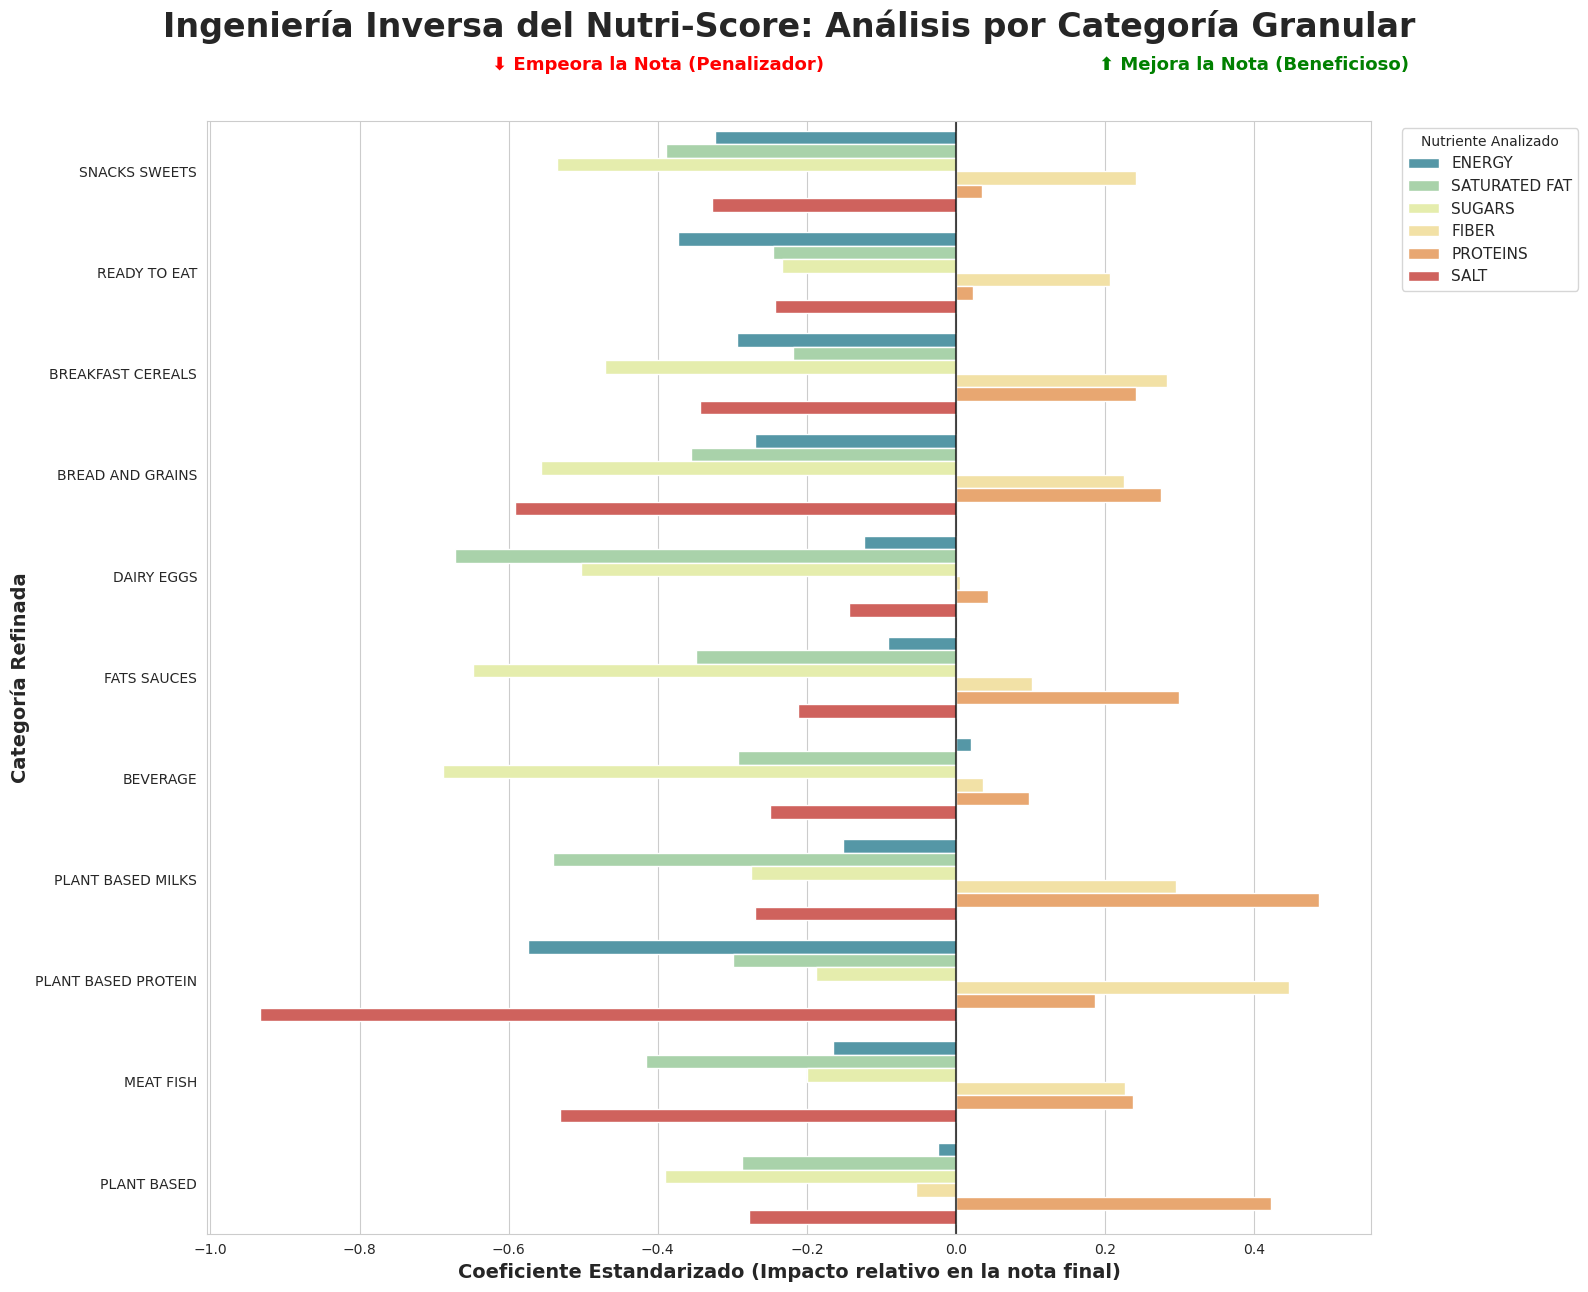

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# 1. Preparación del Dataset (A=5, E=1)
df_reg = foods[foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])].copy()
df_reg['nutri_numeric'] = df_reg['nutriscore_grade'].map({'a': 5, 'b': 4, 'c': 3, 'd': 2, 'e': 1})

# Nutrientes del algoritmo oficial
nutrientes = ['energy-kcal_100g', 'saturated-fat_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g']

# Lista de categorías granulares
categories = [
    'snacks_sweets', 'ready_to_eat', 'breakfast_cereals', 'bread_and_grains', 
    'dairy_eggs', 'fats_sauces', 'beverage', 'plant_based_milks', 
    'plant_based_protein', 'meat_fish', 'plant_based'
]

results = []

# 2. Motor de Regresión
for cat in categories:
    cat_data = df_reg[df_reg['category_unified'] == cat].dropna(subset=nutrientes + ['nutri_numeric'])
    
    if len(cat_data) > 15:
        X = cat_data[nutrientes]
        y = cat_data['nutri_numeric']
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        model = LinearRegression()
        model.fit(X_scaled, y)
        
        for i, nutri in enumerate(nutrientes):
            results.append({
                'category': cat.replace('_', ' ').upper(),
                'nutrient': nutri.replace('-kcal_100g', '').replace('_100g', '').replace('-', ' ').upper(),
                'coefficient': model.coef_[i]
            })

df_results = pd.DataFrame(results)

# 3. Visualización con MARGEN SUPERIOR CORREGIDO
plt.figure(figsize=(16, 14))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=df_results, 
    x='coefficient', 
    y='category', 
    hue='nutrient', 
    palette="Spectral_r"
)

plt.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)

# Título con mayor separación (pad)
plt.title("Ingeniería Inversa del Nutri-Score: Análisis por Categoría Granular", 
          fontsize=24, pad=60, fontweight='bold')

plt.xlabel("Coeficiente Estandarizado (Impacto relativo en la nota final)", fontsize=14, fontweight='bold')
plt.ylabel("Categoría Refinada", fontsize=14, fontweight='bold')
plt.legend(title="Nutriente Analizado", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)

# Ajustamos la posición de las leyendas de ayuda para que no se solapen
# El valor -1.0 las aleja más hacia arriba del primer grupo de barras
plt.text(0.4, -1.0, "⬆️ Mejora la Nota (Beneficioso)", color='green', fontweight='bold', ha='center', fontsize=13)
plt.text(-0.4, -1.0, "⬇️ Empeora la Nota (Penalizador)", color='red', fontweight='bold', ha='center', fontsize=13)

# REGLA DE ORO: tight_layout con rect permite dejar espacio arriba para el título
plt.tight_layout(rect=[0, 0, 1, 0.93]) 

plt.show()

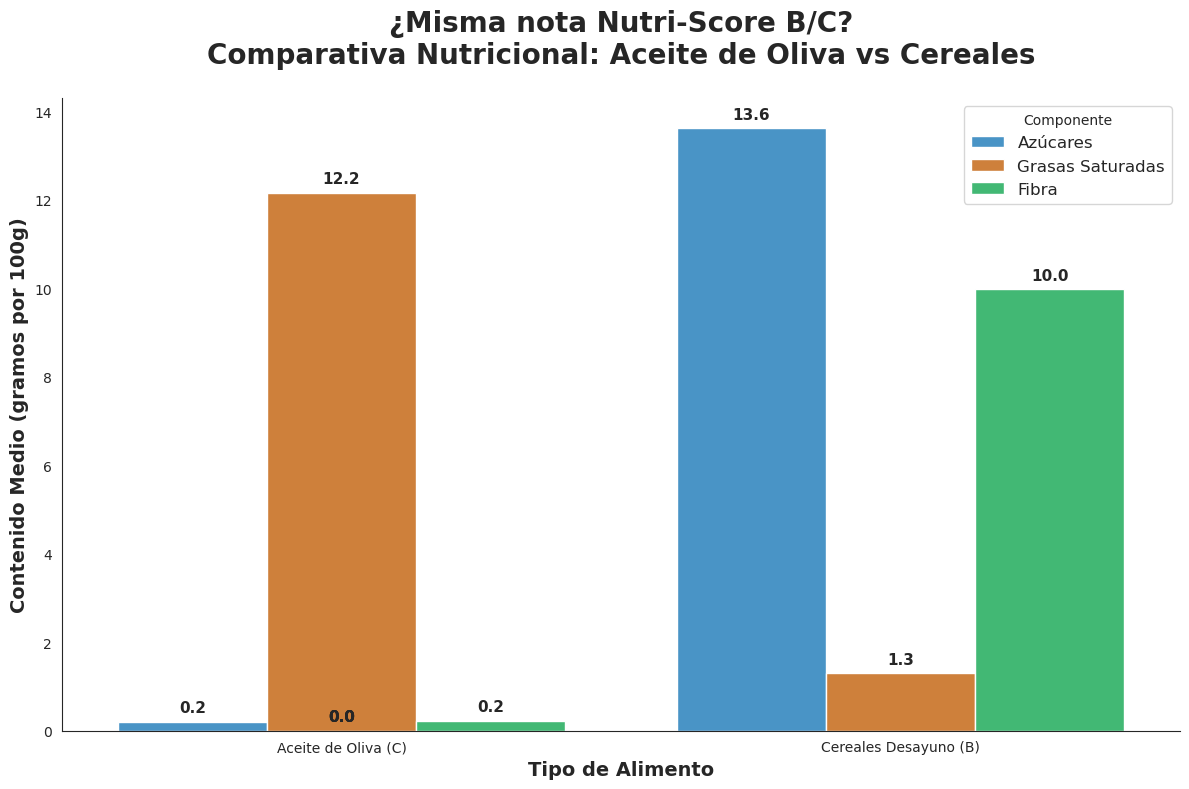

In [12]:
# --- [ED-06] CRÍTICA: ACEITE DE OLIVA VS CEREALES (Foco Nutricional) ---

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filtrado de los dos grupos enfrentados
# Aceites de Oliva (B/C) - Usamos una búsqueda por nombre para mayor precisión
aceites = foods[
    (foods['product_name'].str.contains('olive oil|aceite de oliva|huile d\'olive', case=False, na=False)) &
    (foods['nutriscore_grade'].isin(['b', 'c']))
].copy()
aceites['group_label'] = 'Aceite de Oliva (C)'

# Cereales de Desayuno (B) - La "Falsa Excelencia"
cereales = foods[
    (foods['category_unified'] == 'breakfast_cereals') &
    (foods['nutriscore_grade'] == 'b')
].copy()
cereales['group_label'] = 'Cereales Desayuno (B)'

# 2. Preparamos los datos para la comparativa de nutrientes
df_comp = pd.concat([aceites, cereales])
nutri_cols = ['sugars_100g', 'saturated-fat_100g', 'fiber_100g']

# Calculamos las medias y transformamos a formato largo para Seaborn
df_means = df_comp.groupby('group_label')[nutri_cols].mean().reset_index()
df_melted = df_means.melt(id_vars='group_label', var_name='Nutriente', value_name='g_100g')

# 3. Visualización con colores estratégicos
plt.figure(figsize=(12, 8))
sns.set_style("white")

# Paleta personalizada: Azul (Azúcar), Naranja (Grasa), Verde (Fibra)
paleta_nutri = {
    'sugars_100g': '#3498db', 
    'saturated-fat_100g': '#e67e22', 
    'fiber_100g': '#2ecc71'
}

ax = sns.barplot(
    data=df_melted,
    x='group_label',
    y='g_100g',
    hue='Nutriente',
    palette=paleta_nutri
)

# 4. Estética y Anotaciones
plt.title("¿Misma nota Nutri-Score B/C?\nComparativa Nutricional: Aceite de Oliva vs Cereales", 
          fontsize=20, fontweight='bold', pad=25)
plt.xlabel("Tipo de Alimento", fontsize=14, fontweight='bold')
plt.ylabel("Contenido Medio (gramos por 100g)", fontsize=14, fontweight='bold')

# Renombramos la leyenda para que sea legible
labels = ['Azúcares', 'Grasas Saturadas', 'Fibra']
h, _ = ax.get_legend_handles_labels()
plt.legend(h, labels, title="Componente", fontsize=12, loc='upper right')

# Añadimos los valores exactos sobre cada barra para mayor claridad
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

sns.despine() # Quita el marco para un look más moderno
plt.tight_layout()
plt.show()

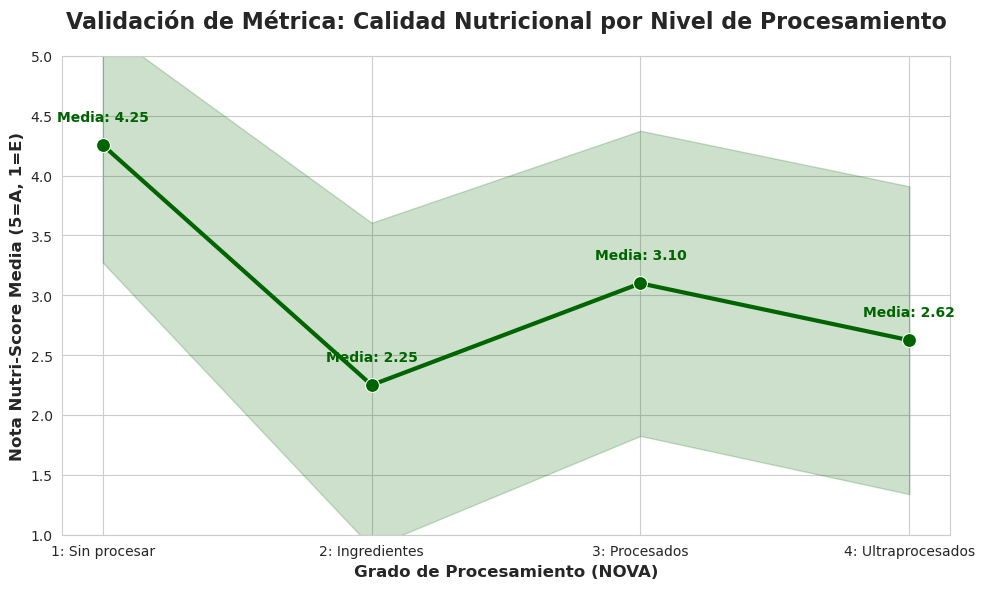

--- Resumen de Validación NOVA vs Nutri-Score ---
   nova_group      mean       std  count
0           1  4.254342  0.981101    806
1           2  2.250000  1.355592    292
2           3  3.099500  1.274524   2000
3           4  2.624502  1.285515   4269


In [13]:
# --- [ED-08] VALIDACIÓN DE ROBUSTEZ: CORRELACIÓN NUTRI-SCORE vs NOVA ---

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparación de datos: Filtramos nulos y grados no válidos
# Aseguramos que solo trabajamos con la escala real
df_val = foods[
    (foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])) & 
    (foods['nova_group'].isin([1, 2, 3, 4]))
].copy()

# 2. Conversión a escala numérica para cálculo de promedios
# A=5 (Excelente), E=1 (Pobre)
df_val['nutri_numeric'] = df_val['nutriscore_grade'].map({'a': 5, 'b': 4, 'c': 3, 'd': 2, 'e': 1})

# 3. Cálculo de la "Escalera de Procesamiento"
resumen_nova = df_val.groupby('nova_group')['nutri_numeric'].agg(['mean', 'std', 'count']).reset_index()

# 4. Visualización de la Tendencia
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Dibujamos la línea de tendencia con puntos
ax = sns.lineplot(data=df_val, x='nova_group', y='nutri_numeric', 
                  marker='o', markersize=10, color='darkgreen', linewidth=3, errorbar='sd')

# Estética del gráfico
plt.title("Validación de Métrica: Calidad Nutricional por Nivel de Procesamiento", 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Grado de Procesamiento (NOVA)", fontsize=12, fontweight='bold')
plt.ylabel("Nota Nutri-Score Media (5=A, 1=E)", fontsize=12, fontweight='bold')
plt.xticks([1, 2, 3, 4], ['1: Sin procesar', '2: Ingredientes', '3: Procesados', '4: Ultraprocesados'])
plt.ylim(1, 5)

# Añadimos etiquetas de valor sobre los puntos
for x, y in zip(resumen_nova['nova_group'], resumen_nova['mean']):
    plt.text(x, y + 0.2, f"Media: {y:.2f}", ha='center', fontweight='bold', color='darkgreen')

plt.tight_layout()
plt.show()

# 5. Verificación estadística para la memoria
print("--- Resumen de Validación NOVA vs Nutri-Score ---")
print(resumen_nova)

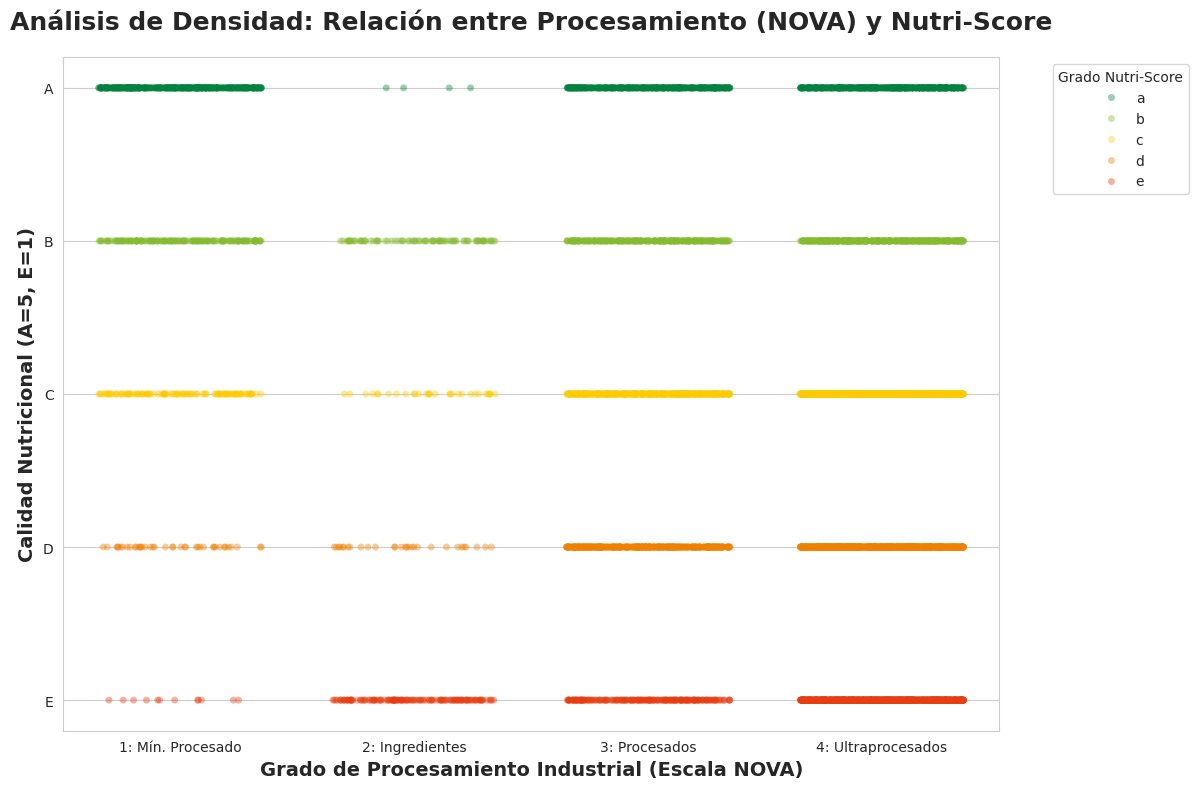

In [14]:
# --- [ED-09] SCATTERPLOT DE RELACIÓN: NUTRI-SCORE VS NOVA ---

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparación de datos
# Asegúrate de cargar tu dataset limpio (ej: foods_cleaned.csv)
# df = pd.read_csv('tu_archivo_limpio.csv')

# Filtramos para tener solo datos válidos y útiles para la tesis
df_plot = foods[(foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])) & 
             (foods['nova_group'].isin([1, 2, 3, 4]))].copy()

# Mapeamos Nutri-Score a valores numéricos para el eje Y
df_plot['nutri_numeric'] = df_plot['nutriscore_grade'].map({'a': 5, 'b': 4, 'c': 3, 'd': 2, 'e': 1})

# Paleta oficial de colores Nutri-Score
nutri_palette = {'a': '#038141', 'b': '#85BB2F', 'c': '#FECB02', 'd': '#EE8100', 'e': '#E63E11'}

# 2. Visualización: Scatter plot con Jitter (Stripplot)
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Usamos stripplot para simular un scatterplot y ver la densidad de puntos
ax = sns.stripplot(
    data=df_plot, 
    x='nova_group', 
    y='nutri_numeric', 
    hue='nutriscore_grade', 
    hue_order=['a', 'b', 'c', 'd', 'e'],
    palette=nutri_palette,
    size=5, 
    alpha=0.4, # Transparencia para ver dónde se acumulan más productos
    jitter=0.35, 
    dodge=False
)

# 3. Formato y etiquetas académicas
plt.title("Análisis de Densidad: Relación entre Procesamiento (NOVA) y Nutri-Score", 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Grado de Procesamiento Industrial (Escala NOVA)", fontsize=14, fontweight='bold')
plt.ylabel("Calidad Nutricional (A=5, E=1)", fontsize=14, fontweight='bold')

# Personalizamos los ejes para que sean legibles en la memoria
plt.xticks([0, 1, 2, 3], ['1: Mín. Procesado', '2: Ingredientes', '3: Procesados', '4: Ultraprocesados'])
plt.yticks([1, 2, 3, 4, 5], ['E', 'D', 'C', 'B', 'A'])

plt.legend(title="Grado Nutri-Score", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()